In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [60]:
# Load datasets. These were downloaded from NHANES website (2017-2018 cycle) 
slq = pd.read_sas(r"C:\Users\brigi\Downloads\NHANES 2017-2018\SLQ_J.xpt")
dpq = pd.read_sas(r"C:\Users\brigi\Downloads\NHANES 2017-2018\DPQ_J.xpt")

In [61]:
print(slq.shape)
print(dpq.shape)

(6161, 11)
(5533, 11)


In [62]:
slq.head()

,SEQN,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120
0,93705.0,b'23:00',b'07:00',8.0,b'23:00',b'07:00',8.0,2.0,5.397605e-79,2.0,5.397605e-79
1,93706.0,b'23:30',b'10:00',10.5,b'00:30',b'12:00',11.5,1.0,5.397605e-79,2.0,1.000000e+00
2,93708.0,b'22:30',b'06:30',8.0,b'22:30',b'06:30',8.0,9.0,5.397605e-79,2.0,2.000000e+00
3,93709.0,b'22:30',b'05:30',7.0,b'22:30',b'05:00',6.5,1.0,5.397605e-79,2.0,1.000000e+00
4,93711.0,b'22:00',b'05:00',7.0,b'23:00',b'08:00',9.0,2.0,1.000000e+00,1.0,3.000000e+00


In [63]:
dpq.head()

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
0,93705.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN
1,93706.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN
2,93708.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN
3,93709.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,93711.0,1.000000e+00,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79


In [64]:
# Merge the sleep and depression dataframes on the SEQN column (which is the unique identifier for each participant)
# Note: we use an inner join to keep only participants who have data in both dataframes
df = pd.merge(slq, dpq, on='SEQN', how='inner')

In [65]:
print(df.shape)

(5533, 21)


> **Note on sample:** The sleep questionnaire (SLQ) was completed by 6,161 participants, while the depression questionnaire (DPQ) was completed by 5,533. The inner join retains only the 5,533 participants who completed both. The ~628 people with sleep data but no depression screening are excluded, and it is possible they differ systematically from those who were screened.

In [66]:
# SLQ120 asks "In the past month, how often did you feel excessively or overly sleepy during the day?"
# 0 = Never
# 1 = Rarely (1 time per month)
# 2 = Sometimes (2-4 times per month)
# 3 = Often (5-15 times per month)
# 4 = Almost Always (16-30 times per month)
# 7 = Refused
# 9 = Don't know
df['SLQ120'].describe()

count    5.533000e+03
mean     1.796855e+00
std      1.218060e+00
min      5.397605e-79
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      9.000000e+00
Name: SLQ120, dtype: float64

In [67]:
# For the depression questions, we will use the PHQ-9 total score, 
# which is calculated by summing the responses to the 9 depression questions (DPQ010 to DPQ090). 
# Each question is scored from 0 to 3, so the total score can range from 0 to 27.
df[['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']].describe()

,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090
count,5.094000e+03,5.093000e+03,5.093000e+03,5.092000e+03,5.092000e+03,5.091000e+03,5.091000e+03,5.091000e+03,5.090000e+03
mean,3.992933e-01,3.593167e-01,6.465737e-01,7.617832e-01,3.994501e-01,2.567276e-01,2.722451e-01,1.791397e-01,6.149312e-02
std,8.201561e-01,7.668570e-01,9.911066e-01,9.754442e-01,8.171601e-01,7.001904e-01,7.219092e-01,6.272503e-01,3.969209e-01
min,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
50%,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
75%,1.000000e+00,5.397605e-79,1.000000e+00,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
max,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00


In [68]:
# Replace 7 and 9 in SLQ120 and the depression questions with NaN
# Note: DPQ100 is not part of the PHQ-9 scoring
dpq_cols = ['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']
cols_needed = ['SLQ120'] + dpq_cols
df[cols_needed] = df[cols_needed].replace([7,9], float('nan'))

In [69]:
df[cols_needed].max()

SLQ120    4.0
DPQ010    3.0
DPQ020    3.0
DPQ030    3.0
DPQ040    3.0
DPQ050    3.0
DPQ060    3.0
DPQ070    3.0
DPQ080    3.0
DPQ090    3.0
dtype: float64

In [70]:
# Convert floats to integers by rounding
df[cols_needed] = df[cols_needed].round()


In [71]:
# Drop rows with missing values in SLQ120 or any of the depression questions
df = df.dropna(subset=cols_needed)
print(df.shape)

(5060, 21)


In [72]:
# Make sure the tiny float values are now zeros
(df[cols_needed] == 0).sum()

SLQ120     800
DPQ010    3776
DPQ020    3846
DPQ030    3105
DPQ040    2571
DPQ050    3793
DPQ060    4216
DPQ070    4220
DPQ080    4522
DPQ090    4869
dtype: int64

In [73]:
# Compute the PHQ-9 total score by summing the 9 depression questions
df['phq9_score'] = df[dpq_cols].sum(axis=1)
df['phq9_score'].describe()

count    5060.000000
mean        3.240711
std         4.244476
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        25.000000
Name: phq9_score, dtype: float64

array([[<Axes: title={'center': 'SLQ120'}>,
        <Axes: title={'center': 'phq9_score'}>]], dtype=object)

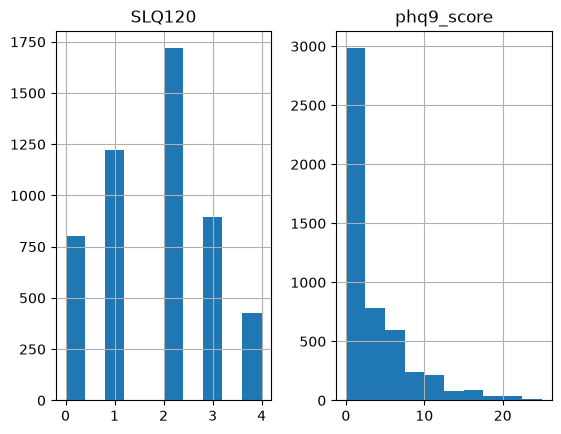

In [74]:
# Plot histograms of daytime sleepiness and PHQ-9 scores
df[['SLQ120', 'phq9_score']].hist()

In [75]:
# what is the frequency of each level of daytime sleepiness?
df['SLQ120'].value_counts().sort_index()

SLQ120
0.0     800
1.0    1221
2.0    1718
3.0     893
4.0     428
Name: count, dtype: int64

In [76]:
# Run both a Pearson and Spearman correlation between daytime sleepiness and PHQ-9 scores
# Running Spearman because both variables are ordinal, and the depression score is right-skewed, 
# while Pearson assumes both variables are continuous and normally distributed
pearson_r, pearson_p = stats.pearsonr(df['SLQ120'], df['phq9_score'])
spearman_r, spearman_p = stats.spearmanr(df['SLQ120'], df['phq9_score'])

print(f"Pearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman correlation: r = {spearman_r:.3f}, p = {spearman_p:.4f}")

Pearson correlation: r = 0.359, p = 0.0000
Spearman correlation: r = 0.397, p = 0.0000


### Correlation results

**Coefficient (r):** Both the Pearson (0.359) and Spearman (0.397) correlations are positive and in the moderate range (0.30–0.50). People who experience daytime sleepiness more frequently tend to have higher PHQ-9 scores.

**p-value:** Both p-values are essentially zero, so the relationship is statistically significant.

**Conclusion:** Daytime sleepiness and depression severity co-occur. This is a correlational finding — it does not tell us which one causes the other.

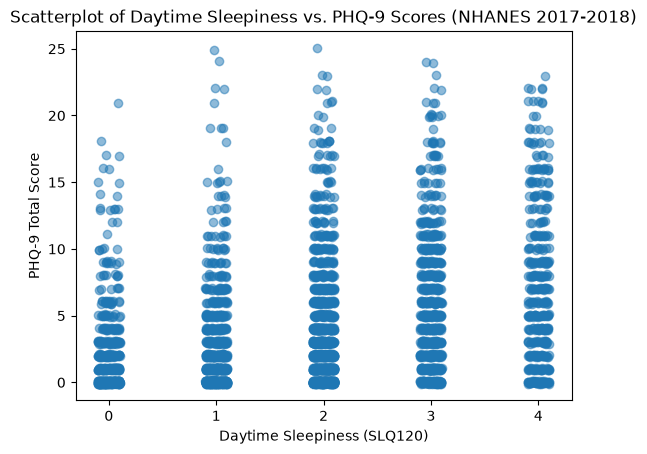

In [77]:
# Create a scatterplot of daytime sleepiness vs. PHQ-9 scores
# Use jittering to spread out the points since both variables are ordinal
plt.scatter(df['SLQ120'] + np.random.uniform(-0.1, 0.1, size=df.shape[0]), 
            df['phq9_score'] + np.random.uniform(-0.1, 0.1, size=df.shape[0]),
            alpha=0.5)
plt.xlabel('Daytime Sleepiness (SLQ120)')
plt.ylabel('PHQ-9 Total Score')
plt.title('Scatterplot of Daytime Sleepiness vs. PHQ-9 Scores (NHANES 2017-2018)')
plt.show()

In [78]:
# Scatterplot may not be the best way to visualize this relationship since both variables are ordinal.

# Let's try a box plot and a violin plot instead.

# Pull out the phq9 scores for each sleepiness level (0-4) as a list of arrays.
groups = [df[df['SLQ120'] == level]['phq9_score'].values for level in range(5)]

In [79]:
len(groups)

5

In [80]:

len(groups[0])

800

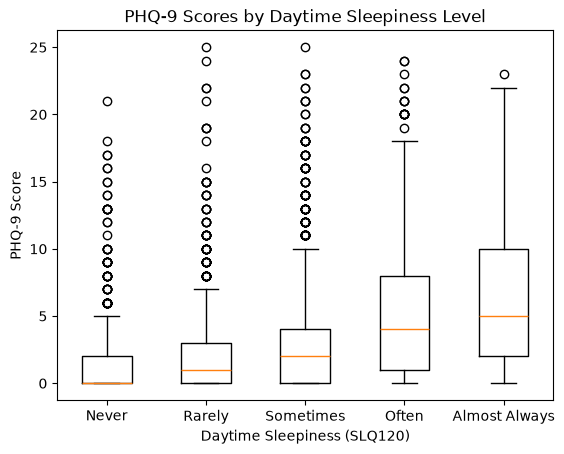

In [81]:
# Box plot of PHQ-9 scores by daytime sleepiness level
fig, ax = plt.subplots()
ax.boxplot(groups)
ax.set_xticklabels(['Never', 'Rarely', 'Sometimes', 'Often', 'Almost Always'])
ax.set_xlabel('Daytime Sleepiness (SLQ120)')
ax.set_ylabel('PHQ-9 Score')
ax.set_title('PHQ-9 Scores by Daytime Sleepiness Level')
plt.savefig(r"C:\Users\brigi\source\repos\brigitschroeder\public\images\002-sleep-boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

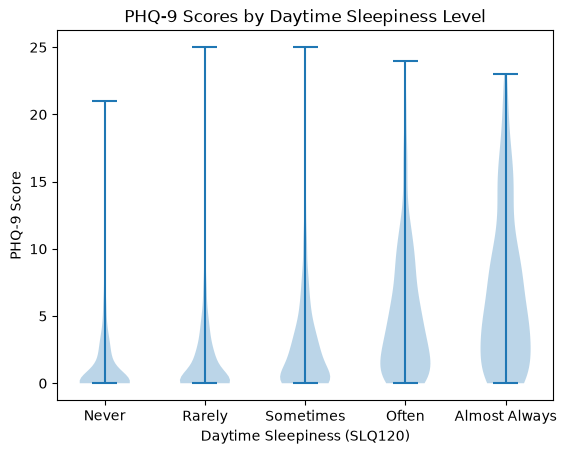

In [82]:
# Now we'll try a violin plot, which shows the distribution of PHQ-9 scores for each sleepiness level
fig, ax = plt.subplots()
ax.violinplot(groups)
ax.set_xticks([1, 2, 3, 4, 5])  # Set x-ticks to match the number of groups
ax.set_xticklabels(['Never', 'Rarely', 'Sometimes', 'Often', 'Almost Always'])
ax.set_xlabel('Daytime Sleepiness (SLQ120)')
ax.set_ylabel('PHQ-9 Score')
ax.set_title('PHQ-9 Scores by Daytime Sleepiness Level')
plt.show()

### Observations

- **The relationship looks roughly linear.** Median PHQ-9 scores increase steadily across the five sleepiness levels, which is a good sign for linear regression.
- **Variance is not constant (heteroscedasticity).** The spread of PHQ-9 scores grows as sleepiness increases. In the violin plot, the width at any y-value represents how many people scored there: the "Never" group is widest near zero, while the "Often" and "Almost Always" groups are wider in the mid-range. This is a violation of the homoscedasticity assumption for linear regression.

### Linear regression assumptions

1. **Linearity** — the relationship between X and Y is linear. The boxplot suggests this is roughly satisfied.
2. **Independence** — each observation is independent. NHANES uses complex survey sampling, which is mostly handled by design; for this analysis we treat observations as independent.
3. **Normality of residuals** — the errors (predicted minus actual) should be roughly normally distributed. This is about the residuals, not the raw outcome.
4. **Homoscedasticity** — the spread of residuals should be roughly constant across all values of X. The violin plot flags this as a potential concern.

**Options if assumptions are violated:**

| Option | When to use it |
| --- | --- |
| Transform Y (e.g., `log(phq9 + 1)`) | Right-skewed outcome, heteroscedasticity |
| Robust standard errors | Heteroscedasticity, prefer not to transform |
| Ordinal logistic regression | Outcome is ordinal, not truly continuous |
| Poisson/negative binomial regression | Outcome is a count (PHQ-9 is a count) |

For this analysis I will use **log-transformed linear regression** — it is interpretable and appropriate for a learning exercise. Heteroscedasticity will be noted as a limitation.

In [83]:
# Transform the PHQ-9 scores using a log transformation to see if that helps with the heteroscedasticity in the scatterplot
df['phq9_log'] = np.log(df['phq9_score'] + 1)  # Add 1 to avoid log(0) which is undefined

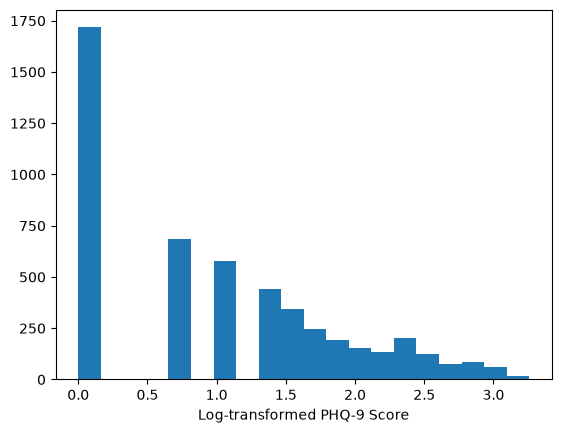

In [84]:
# Plot a histogram of the log-transformed PHQ-9 scores to see if they are more normally distributed
plt.hist(df['phq9_log'], bins=20)
plt.xlabel('Log-transformed PHQ-9 Score')
plt.show()

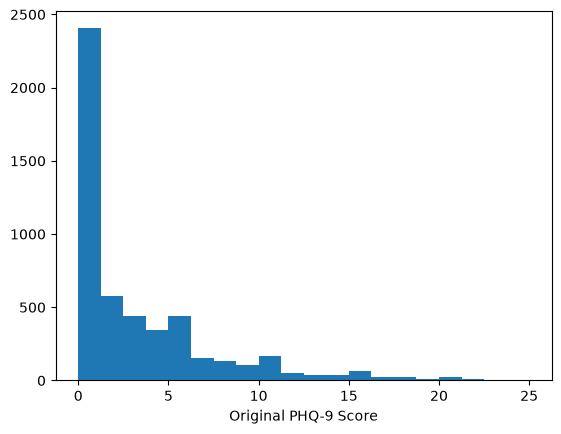

In [85]:
# Compare to the original histogram of PHQ-9 scores
plt.hist(df['phq9_score'], bins=20)
plt.xlabel('Original PHQ-9 Score')
plt.show()

### Histogram comparison

The original PHQ-9 scores ranged from 0–25 with a long right tail. After `log(x + 1)` transformation the range compresses to 0–3.3, and the tail is much less extreme — which is what we wanted.

The large spike at zero remains. Approximately 1,700 participants reported no depression symptoms, so `log(0 + 1) = 0` for all of them. No transformation can spread out a true spike of zeros; this is a data characteristic, not an error.

With n = 5,060, the central limit theorem provides protection against non-normality in the residuals, so we can proceed.

In [86]:
# Run the regression and compute predicted values and residuals
slope, intercept, r, p, se = stats.linregress(df['SLQ120'], df['phq9_log'])
r_squared = r ** 2
print(f'slope: {slope:.3f}, intercept: {intercept:.3f}, r: {r:.3f}, R2: {r_squared:.3f}, p: {p:.4f}, se: {se:.3f}')

df['predicted'] = intercept + slope * df['SLQ120']
df['residuals'] = df['phq9_log'] - df['predicted']

slope: 0.311, intercept: 0.468, r: 0.397, p: 0.0000, se: 0.010


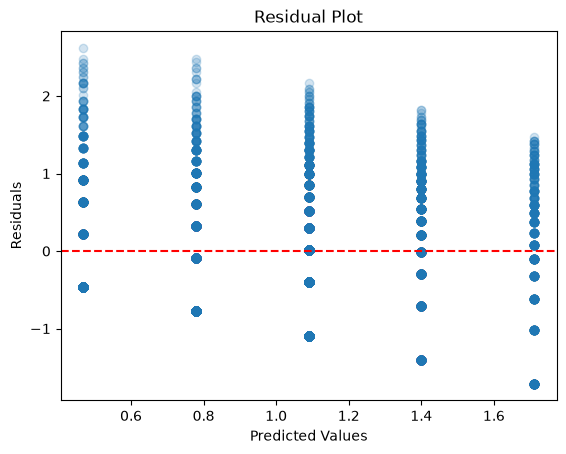

In [87]:
fig, ax = plt.subplots()
ax.scatter(df['predicted'], df['residuals'], alpha=0.2)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residual Plot')
plt.savefig(r"C:\Users\brigi\source\repos\brigitschroeder\public\images\002-sleep-residuals.png", dpi=150, bbox_inches='tight')
plt.show()

### Residual plot interpretation

The five vertical columns correspond to the five possible values of SLQ120 (0–4) — because the predictor is ordinal with only five levels, there are only five possible predicted values.

The spread of residuals *decreases* as sleepiness increases (the leftmost column reaches ~2.7; the rightmost reaches ~1.4). This is heteroscedasticity in the opposite direction from what we saw before the transformation. The log transform reduced the problem but did not eliminate it. This will be noted as a limitation in the write-up.

The slope (0.311) and r (0.397) match the earlier Spearman correlation closely, and the p-value remains essentially zero.

### R²

R² = 0.397² ≈ **0.158**

About **16% of the variation in PHQ-9 scores is explained by daytime sleepiness frequency.** The remaining 84% reflects other factors not captured in this model (other health conditions, life circumstances, genetics, etc.). For a single-variable model in behavioral health data, 16% is a meaningful but modest result.

In [88]:
# Calculate the mean log-PHQ9 for each sleepiness level
group_means = df.groupby('SLQ120')['phq9_log'].mean()
print(group_means)

SLQ120
0.0    0.568222
1.0    0.719883
2.0    1.035456
3.0    1.490415
4.0    1.719816
Name: phq9_log, dtype: float64


> **Note:** The jump from "Sometimes" (1.04) to "Often" (1.49) is larger than the other steps, suggesting the relationship may not be perfectly linear. The regression line will split the difference.

In [89]:
# Create the regression line and plot it on top of the scatterplot of daytime sleepiness vs. PHQ-9 scores
x_line = np.linspace(df['SLQ120'].min(), df['SLQ120'].max(), 100)
y_line = intercept + slope * x_line

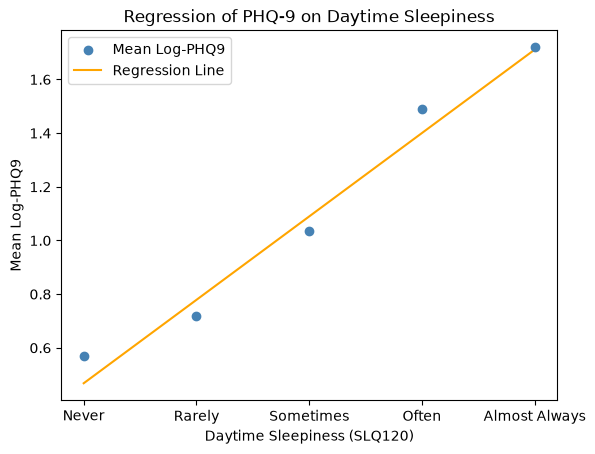

In [90]:
fig, ax = plt.subplots()
ax.scatter(group_means.index, group_means.values, color='steelblue',
           zorder=5, label='Group mean')
ax.plot(x_line, y_line, color='orange', label='Regression line', zorder=4)
ax.set_xlabel('Daytime Sleepiness (SLQ120)')
ax.set_ylabel('Mean Log-Transformed PHQ-9 Score')
ax.set_title('Regression of PHQ-9 on Daytime Sleepiness')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['Never', 'Rarely', 'Sometimes', 'Often', 'Almost Always'])
ax.legend()
plt.savefig(r'C:\Users\brigi\source\repos\brigitschroeder\public\images\002-sleep-regression.png', dpi=150, bbox_inches='tight')
plt.show()

### Regression plot interpretation

Four of the five group means sit close to the regression line, indicating a reasonable linear fit. The exception is "Never" — the actual mean (0.57) is above the line (predicted ~0.47), meaning the model slightly underestimates depression scores for people who are never sleepy.

The gap between "Sometimes" and "Often" is also visible: "Sometimes" sits just below the line while "Often" sits above it, reflecting the larger-than-average step noted in the group means above.